`1a`

# Day 2: Multi-dimensional systems and epidemic models

Today you read the SIR model, then extend it by adding compartments to models like the SIHR hospitalization model. Each model is just boxes, arrow-rates, and one update rule you already know.

In [ ]:
# 1b
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

`2a`

## Session 3: Multi-dimensional systems and epidemic models

`3a`

### Multi-Dimensional Dynamical Systems

A dynamical system describes how a state $X(t)$ evolves over time through a rate equation $\frac{dX}{dt} = f(X)$. The state does not have to be a single variable, it can be a vector of any number of variables, and the same idea extends directly to that case. Here $\frac{dX}{dt}$ just means the rate of change of $X$, that is, how fast $X$ is going up or down right now. You will not compute any derivatives by hand today; the code handles that with the forward-Euler step below.

Epidemic models are exactly this kind of multi-variable system: the state is the number of people in each compartment, for example $X = [S, I, R]$, and $f$ returns how fast each compartment changes. We solve it numerically with the forward-Euler step from earlier this morning,

$$
X_{t+1} = X_t + \Delta t\, f(X_t),
$$

now with $X$ a vector, so $f$ returns a vector of the same length. Today we read the **SIR** model, step it forward, and then **extend** it by adding compartments to models like SIHR.

`4a`

### Reading a Compartmental Model

Epidemic models track interacting groups of people (susceptible, infected, recovered), each group with its own rate function. Before the equations, three questions to ask of *any* epidemic model:

- **Compartments**, what are the boxes? Each is a group of people in one state (Susceptible, Infected, Recovered, …). Everyone is in exactly one box, and the boxes always sum to the total population $N$.
- **Parameters**, what do the rates mean? $\beta$ is the transmission rate (how fast S → I) and $\gamma$ the recovery rate (how fast I → R). Bigger models add more rates, but every arrow still carries exactly one.
- **Assumptions**, what are we pretending is true? These models assume a **well-mixed** population (anyone can meet anyone), a **closed** population (no births, deaths, or travel, so $N$ is constant), and the **same rates for everyone**.

Keep these three questions visible as we read SIR and then extend it to models like SIHR.

Here is the SIR model drawn that way: three boxes, two arrows, each arrow labeled with its rate.

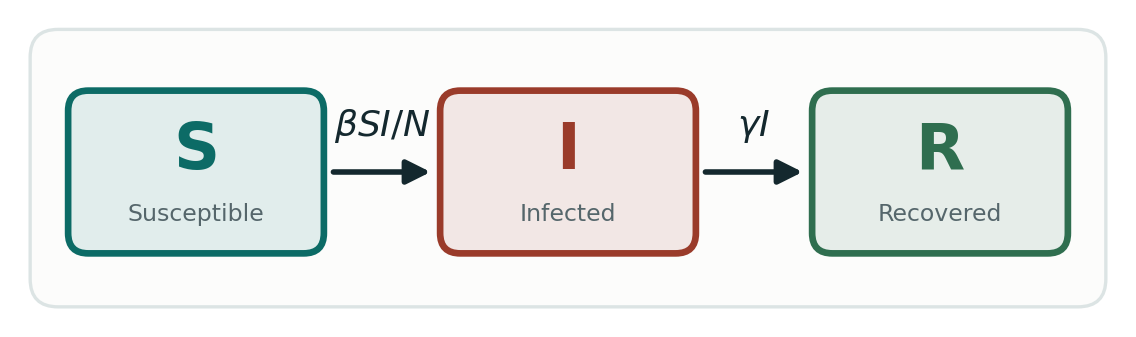

`5a`

### Where the infection term comes from

The transmission flow $\beta S I / N$ is the least obvious piece of the model, so it is worth building one factor at a time:

- $\dfrac{I}{N}$ is the **fraction of the population that is infected**, that is, the chance a random contact is with an infected person.
- $S \cdot \dfrac{I}{N}$ multiplies that chance by the number of susceptible people, giving the number of susceptible-infected pairs.
- Multiplying by $\beta$ (the transmission rate) turns those pairs into **new infections per unit time**: $\dfrac{\beta S I}{N}$.

The same term appears with **opposite signs** in two equations: it leaves $S$ (a loss, $-\beta S I/N$) and enters $I$ (a gain, $+\beta S I/N$). That paired minus and plus is what keeps the population conserved.

*Optional, for the curious:* this assumption has a name, **mass-action incidence**. The idea comes from chemistry, where a reaction runs at a rate proportional to the product of how much of each ingredient is present. Here the ingredients are susceptible and infected people, so new infections scale with the product $S \times I$. Because we divide by $N$ and use the *fraction* infected $I/N$ rather than the raw count, this version is called **frequency-dependent**: each susceptible person's risk depends on what fraction of their contacts are infected, not on the size of the crowd, which is what keeps $\beta$ meaningful whether the population is 500 or 5 million.

`6a`

### Reading the rates, and choosing $\gamma$ from data

A rate times a count is a flow. The recovery term $\gamma I$ says: if $\gamma = 0.2$ and $I = 100$, then $\gamma I = 20$ people recover per day. So $\gamma$ is not a probability and not a count; it is a *per-person, per-day* rate.

That reading also tells us how to **choose** $\gamma$ from data. If people stay infectious for about $D$ days, then a fraction $1/D$ of them recover each day, so

$$
\gamma \approx \frac{1}{D}.
$$

For influenza the infectious period is roughly 4 to 7 days, which puts $\gamma$ between $1/7 \approx 0.14$ and $1/4 = 0.25$. That number $D$ is simply how long someone with the flu typically stays contagious, the same kind of real flu picture you looked at in the Arizona data on Day 1. The same logic sets $\beta$, which is contacts per day times the chance an encounter transmits.

`7a`

### Writing every model the same way

Every epidemic model can be written as a **rate function** `rhs(X)` that returns how fast each compartment changes, then stepped forward with a short Euler loop. We write the SIR model this way, then reuse the exact same pattern to extend it.

One approach is to hard-code each box's update by hand inside the loop, but that hides the rule inside the stepping. Instead we pull the rule out into its own **rate function** `rhs(X)` and reuse one generic Euler loop. Separating the *model* from the *stepping* is the key idea: the loop never changes, so to add a compartment you only add a line to `rhs`. The two forms do exactly the same arithmetic:

For the susceptible box, for example:

- inline in the loop, `S_next = S - dt * infections`;
- as a rate function, `rhs` returns `dS = -infections`, and one generic loop does `xs[k] = xs[k-1] + dt * rhs(xs[k-1])` for every box at once.

`8a`

### SIR Model

For many diseases such as influenza, people who recover cannot be reinfected within the same season and effectively leave the dynamics. The **SIR** model captures this with three compartments, Susceptible, Infected, and Recovered (or removed).

$$
\begin{aligned}
\frac{dS}{dt} &= -\frac{\beta S I}{N} \\
\frac{dI}{dt} &= \frac{\beta S I}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{aligned}
$$

where $N = S + I + R$. People who recover do not reenter the disease dynamics, hence "removed".

In [ ]:
# 8b
# Worked example: simulate the SIR model.
# We add a third compartment R to the same Euler loop.
par = np.array([0.3, 0.1])            # beta, gamma
delta_t = 0.1
ts = np.arange(0, 100 + delta_t, delta_t)

xs = np.zeros((len(ts), 3))
xs[0, :] = np.array([495., 5., 0.])    # S, I, R   (N = 500)

def sir_rhs(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return np.array([dS, dI, dR])

for t_index in range(1, len(ts)):
    x_prev = xs[t_index - 1]
    xs[t_index] = x_prev + delta_t * sir_rhs(x_prev, par)

print('population sum (stays 500):', round(xs[-1].sum(), 1))

plt.title('SIR Model')
plt.plot(ts, xs, label=['Susceptible', 'Infected', 'Recovered'])
plt.xlabel('Time')
plt.ylabel('Number of people')
plt.legend()
plt.show()

`9a`

### Exercise 1 (you try)

The cell above simulates the SIR model ($\beta = 0.3$, $\gamma = 0.1$, $S=495$, $I=5$, $R=0$).

**Core:** at the current values $R_0 = \beta/\gamma = 0.3/0.1 = 3$, so the epidemic grows. To find the threshold, raise `gamma` (recover faster) and rerun a few times, for example 0.2, then 0.3, then 0.35, and watch the Infected curve. The value where it stops taking off and just flattens is the $R_0 = \beta/\gamma = 1$ threshold, where $R_0$ (the basic reproduction number) is $\beta$ over $\gamma$. Above it the epidemic grows; below it, it fizzles out.

`10a`

### Drawing bigger models

The SIR framework extends to any number of compartments; other examples include SEIR (an Exposed box, for diseases with an incubation delay) and SIHR (a Hospitalized box). Using the same box-and-arrow picture from earlier, here is a bigger model, SIHR:

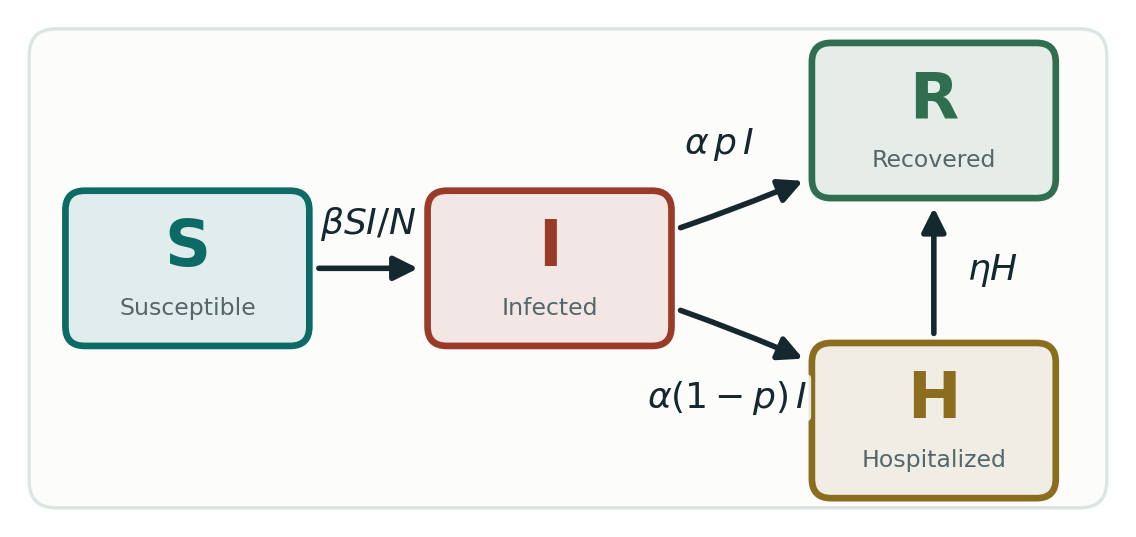

Reading the arrows: infected people leave $I$ at rate $\alpha$; a fraction, drawn as $p$ in the sketch above, recover directly ($\alpha p I$ into $R$) while the remaining fraction $(1-p)$ are hospitalized ($\alpha(1-p)I$ into $H$), and hospitalized people are discharged to $R$ at rate $\eta$ ($\eta H$). Note that $p$ is a *fraction* (between 0 and 1), unlike the recovery *rate* $\gamma$ in the SIR model. (A fully worked SIHR build is in the solutions notebook, if you want to see one.)

`11a`

### Turning any compartment diagram into code

You have now written this loop for SIR. Here are the steps for **any** model you draw:

1. **Count the boxes.** That is the width of your `xs` array and your `x0`.
2. **Name them** in the unpacking line: `S, I, R, ... = X`.
3. For **each box**, write one line, `dBox = (arrows in) - (arrows out)`, reading the arrows straight off your diagram.
4. `return np.array([...])` in the same order.
5. **Reuse the Euler loop**, or the `simulate()` helper below, so you only ever write the model.
6. **Sanity check:** the boxes must always sum to $N$. Print `xs[-1].sum()`; if it drifts, an arrow leaving one box is not entering another (a sign error).

`12a`

### Your turn (Exercise 2): extend the SIR model (add one compartment)

The advantage of the rate-function form is that you can grow the model. Pick **one** new compartment to add to SIR. Each of these is one new box and one or two new arrows:

- **D, Deaths.** A fraction of infected people die instead of recovering. Split the outflow from $I$: keep $\gamma I$ recovering into $R$, and add a $\mu I$ arrow dying into a new box $D$ (with $\mu$ the death rate).
- **V, Vaccinated.** Susceptible people get vaccinated and skip the disease. Add one arrow out of $S$ into a new box $V$ at rate $\nu S$ (with $\nu$ the vaccination rate).
- **E, Exposed.** People are infected but not yet infectious for a few days. Insert a box $E$ between $S$ and $I$: the infection arrow now points $S \to E$, and a new rate moves $E \to I$.

The seed cell below already runs as plain SIR. Add your box by editing the marked lines, following these steps: one line per box, arrows in minus arrows out, and the total should still sum to $N$. Fully worked examples (SIRD, SIRV, SEIR, and the SIHR hospitalization model) are in the solutions notebook, so you can compare your approach.

In [ ]:
# 12b
# The Euler loop, packaged once so your model is just "write a rhs and pick an x0".
def simulate(rhs, x0, par, days=200, delta_t=0.1):
    """Forward-Euler integrator for any compartment model.

    rhs(X, par) returns the per-unit-time change of each compartment.
    Returns (ts, xs); xs has one row per time step and one column per
    compartment, in the same order as x0.
    """
    ts = np.arange(0, days + delta_t, delta_t)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = x0
    for k in range(1, len(ts)):
        xs[k] = xs[k - 1] + delta_t * rhs(xs[k - 1], par)
    return ts, xs

In [ ]:
# 12c
# Exercise 2 workspace: extend the SIR model by one compartment.
# This starts as a runnable plain SIR. Add your new compartment by editing the marked lines.
x0  = np.array([495., 5., 0.])         # S, I, R   (add a starting value for your new compartment)
par = (0.3, 0.1)                       # beta, gamma   (add a rate for your new arrow)

def my_rhs(X, params):
    S, I, R = X                        # name every compartment (add your new one here)
    N = X.sum()
    beta, gamma = params               # unpack every rate (add your new one here)
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    # TODO (you try): add one line per new compartment: dNew = arrows in - arrows out.
    # Then edit the lines above to route arrows into and out of your new compartment.
    return np.array([dS, dI, dR])

ts, xs = simulate(my_rhs, x0, par, days=200)

print("peak infected:", round(xs[:, 1].max(), 1), "| population sum (should stay", x0.sum(), "):", round(xs[-1].sum(), 3))
plt.plot(ts, xs)
plt.xlabel('Time'); plt.ylabel('People'); plt.title('My compartment model')
plt.show()

`13a`

### Visualization Lab: Comparing Epidemic Scenarios

Before you finish Session 3, this short visualization activity looks not only at simulating a scenario but at deciding which graph best communicates the result.

In [ ]:
# 13b
import pandas as pd

# Reuse the simulate() helper from the steps above: write an rhs, then hand it to simulate().
def sir_rhs_day2(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    return np.array([-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I])

scenario_rows = []
plt.figure(figsize=(8, 4))
for beta_value in [0.15, 0.25, 0.35]:
    ts, sol = simulate(sir_rhs_day2, np.array([495., 5., 0.]), (beta_value, 0.1), days=100)
    plt.plot(ts, sol[:, 1], label=f"beta={beta_value}")
    scenario_rows.append({
        "beta": beta_value, "peak_infected": sol[:, 1].max(), "day_of_peak": ts[sol[:, 1].argmax()]
    })

plt.xlabel("Day")
plt.ylabel("Infected")
plt.title("Comparing Transmission Scenarios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame(scenario_rows)

`14a`

### Exercise 3: Scenario Visualization

**Core:** Change the three `beta` values in the cell above and rerun the graph.

**Stretch:** Complete the bar chart of `peak_infected` in the workspace cell below. The blank is marked; the cell will error until you fill it in, which is expected.

In [ ]:
# 14b
# Exercise 3 workspace (you try): bar chart of peak infected by scenario.
# scenario_rows was built in the cell above (one row per beta, with its peak_infected).
scenario_df = pd.DataFrame(scenario_rows)

plt.figure(figsize=(6, 4))
# TODO (you try): replace ___ with the peak-infected column
plt.bar(scenario_df["beta"].astype(str), ___)
plt.xlabel("beta")
plt.ylabel("Peak infected")
plt.title("Peak Infection by Scenario")
plt.show()

`15a`

### End of Session 3

You read the SIR model, extended it by adding your own compartment (with fully worked examples in the solutions notebook), and compared epidemic scenarios with a visualization. This afternoon you will fit one of these models to flu data using a loss function, and on Day 3 you will fit the hospitalization model to real Arizona hospitalization data.